In [1]:
import polars as pl 

BKS = {
    "tsp": pl.read_csv("../../bks/tsp_bks.csv").with_columns(pl.concat_str(pl.col("instance"), pl.lit(".tsp")).alias("instance")),
    "csp": pl.read_csv("../../bks/csp_bks.csv"),
    "pdptw": pl.read_csv("../../bks/pdptw_bks.csv")
}

In [25]:
import orjson
from typing import Literal, Optional
from dataclasses import dataclass
from abc import abstractmethod, ABC
from functools import cached_property


def primal_gap(obj: float, bks: float, is_feasible: bool) -> float:
    if not is_feasible:
        return 1.0
    if obj == bks:
        return 0.0
    return abs(bks - obj) / max(abs(bks), abs(obj))


@dataclass
class ObjOverTime:
    timestamps: list[float]
    objectives: list[float]
    steps: Optional[list[int]]

    def at(self, t: float):
        # Dichotomic search across timestamps
        left, right = 0, len(self.timestamps) - 1
        if t < self.timestamps[0]:
            return None
        if t > self.timestamps[-1]:
            return self.objectives[-1]
        while left < right:
            idx = (left + right) // 2
            if self.timestamps[idx] == t:
                return self.objectives[idx]
            if self.timestamps[idx] < t:
                left = idx + 1
            else:
                right = idx - 1
        return self.objectives[idx]

    @staticmethod
    def parse(sol_over_time: str):
        # Format [(t:0.423-v:361.000)-(t:0.424-v:360.000)]
        sol_over_time = sol_over_time.replace("(t:", '{"t":')
        sol_over_time = sol_over_time.replace("-step:", ',"step":')
        sol_over_time = sol_over_time.replace("-v:", ',"v":')
        sol_over_time = sol_over_time.replace(")-", "},")
        sol_over_time = sol_over_time.replace(")]", "}]")
        data = orjson.loads(sol_over_time)
            
        # flatten to two lists instead of a list of objects
        timestamps = [point["t"] for point in data]
        if "step" in data[0]:
            steps = [int(point["step"]) for point in data]
        else:
            steps = None
        objectives = [point["v"] for point in data]
        return ObjOverTime(timestamps=timestamps, objectives=objectives, steps=steps)


@dataclass
class Result(ABC):
    problem: Literal["csp", "tsp", "pdptw"]
    instance: str
    oot: ObjOverTime

    @classmethod
    def parse(cls, row: dict):
        full_instance: str = row["instance"]
        _, problem, *_, instance = full_instance.split("/")
        assert problem in ("csp", "tsp", "pdptw")
        return cls(problem, instance, ObjOverTime.parse(row["sol_over_time"]))

    @cached_property
    def bks(self) -> float:
        row = BKS[self.problem].filter(pl.col("instance") == self.instance).select("bks")
        if row.is_empty():
            return 0.0
        return row.item()

    @abstractmethod
    def is_feasible(self, t: float) -> bool:
        """Whether the solution is feasible or not at timestamp t."""

    def primal_gap(self, t: float):
        if not self.is_feasible(t):
            return 1.0
        obj = self.oot.at(t)
        assert obj is not None
        return primal_gap(obj, self.bks, True)


class CSPResult(Result):
    def is_feasible(self, t: float) -> bool:
        return self.oot.at(t) == 0


class PDPTWResult(Result):
    UNROUTED_NODE_PENALTY = 1000000000

    def is_feasible(self, t: float) -> bool:
        obj = self.oot.at(t)
        if obj is None:
            return False
        return obj < PDPTWResult.UNROUTED_NODE_PENALTY


class TSPResult(Result):
    UNROUTED_NODE_PENALTY = 1000000000

    def is_feasible(self, t: float) -> bool:
        obj = self.oot.at(t)
        if obj is None:
            return False
        return obj < TSPResult.UNROUTED_NODE_PENALTY

# Primal gap over time

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def primal_gaps_over_time(results: list[Result], tmax: float):
    gaps = []
    for r in results:
        g = []
        for t in range(int(tmax) + 1):
            g.append(r.primal_gap(t))
        gaps.append(g)
    return np.array(gaps)


def camel_to_snake(name: str) -> str:
    import re
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

def plot_pg_by_bandit(filenames: list[str], tmax: float, reward: Literal["r1", "r2", "r3"]):
    to_concat = []
    for path in filenames:
        df = pl.read_csv(path).filter(pl.col("reward") == reward)
        print(df.columns)
        # Turn camelCase columns to snake_case
        mappings = {col: camel_to_snake(col) for col in df.columns}
        df = df.rename(mappings, strict=False)
        to_concat.append(df.select(pl.col("bandit"), pl.col("instance"), pl.col("sol_over_time")))
    df: pl.DataFrame = pl.concat(to_concat)

    problem = df["instance"][0].split("/")[1]
    # if problem == "tsp":
    # Filter all the results to only keep those that DQN could work with
    valid_instances = df.filter(pl.col("bandit").str.starts_with("dqn"))["instance"].to_list()
    df = df.filter(pl.col("instance").is_in(valid_instances))
    xs = np.arange(int(tmax) + 1)
    for name, bandit in df.group_by(pl.col("bandit")):
        match problem:
            case "csp":
                results = [CSPResult.parse(row) for row in bandit.iter_rows(named=True)]
            case "pdptw":
                results = [PDPTWResult.parse(row) for row in bandit.iter_rows(named=True)]
            case "tsp":
                results = [TSPResult.parse(row) for row in bandit.iter_rows(named=True)]
            case other:
                raise NotImplementedError(f"Not implemented for problem type: {other}")
        arr = primal_gaps_over_time(results, tmax) # type: ignore
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / np.sqrt(arr.shape[0])
        plt.plot(xs, mean, label=name)
        plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
        plt.xlabel("Time (s)")
        plt.ylabel("Primal gap")
        plt.margins(x=0.01, y=0.01)
    plt.legend()

['bandit', 'instance', 'reward', 'timeout', 'seed', 'bestObj', 'solOverTime', 'integralPrimalGap']
['instance', 'bandit', 'reward', 'timeout', 'seed', 'sol_over_time', 'objective', 'integral_primal_gap']


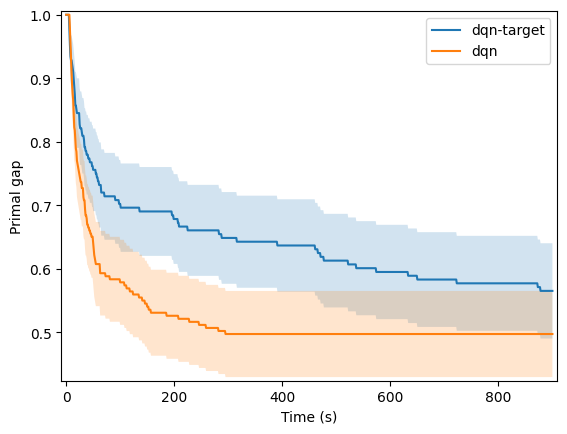

In [26]:
#plot_pg_by_bandit(["csp_bandits.csv", "csp_baseline.csv", "csp_rl.csv", "csp-dist-matrix.csv"], tmax=900, reward="r2")
plot_pg_by_bandit(["csp-target.csv", "csp-r2.csv"], tmax=900, reward="r2")
#plot_pg_by_bandit(["tsp_bandits.csv", "tsp_baseline.csv", "tsp_rl.csv"], tmax=900, reward="r2")
#plot_pg_by_bandit(["csp_bandits.csv", "csp_baseline.csv", "csp_rl.csv"], tmax=900, reward="r2")